# The wide trend sweep

This is the test the trend lane was set up to run. Take the plain trend rule, apply it to every liquid crypto USDT perp on Binance from 2020 to August 2026, and measure the money after costs and funding.

The rule. At each Sunday close, look at a coin's return over the last $L$ weeks. If it rose, go long for the next week. If it fell, go short. Sweep $L$ over 1, 2, 3, 4, 5, 6, 8 and 12 weeks, so every lookback has measured neighbours.

Four books apply it.

- Per coin, \$1M. Every coin trading at least \$1M a day carries its own signal.
- Per coin, \$10M. The same, on coins trading at least \$10M a day.
- Market, \$10M. One signal from the average coin's return, applied to a basket of every \$10M coin, all long or all short together.
- BTC. The rule on BTC alone.

Every position is sized by the inverse of the coin's volatility over the prior 12 weeks, so each coin carries similar risk, and the book's absolute weights sum to one.

## Setup

Load the cleaned weekly panel. Stock, ETF, commodity and tokenised real-asset perps are dropped, so the universe is crypto only. A position set at a Sunday close earns the next week's return and pays that week's funding. Cost is charged on every change of weight. A coin halted at a rebalance keeps its position until it trades again, and books the gap when it does.

Cost is provisional. It is 7.5 bps each way on coins trading at least \$10M a day, which matches the old measured cost table, and 15 bps on smaller coins, which is a guess. Every headline is also run at zero and at twice that cost.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from book import Book, sharpe
import gate

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.25, 'lines.linewidth': 2})
BLUE, ORANGE, AQUA, YELLOW, GREY = '#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#8a8a86'

tb = Book()
W, R, LIQ, VOL, F = tb.W, tb.R, tb.LIQ, tb.VOL, tb.F
run, sized, basket = tb.run, tb.sized, tb.basket
print(f'weeks {len(W)}   {W.index[0].date()} .. {W.index[-1].date()}   coins {W.shape[1]}')

def btc(L):
    w = pd.DataFrame(0.0, index=W.index, columns=W.columns)
    w['BTCUSDT'] = np.sign(W['BTCUSDT'].rolling(L, min_periods=L).sum()).shift(1)
    return w

LOOKBACKS = [1, 2, 3, 4, 5, 6, 8, 12]
BOOKS = {'per coin $1M': lambda L: tb.per_coin(L, 1e6), 'per coin $10M': lambda L: tb.per_coin(L, 1e7),
         'market $10M': lambda L: tb.market(L, 1e7), 'BTC': btc}
weights = {(bk, L): f(L) for bk, f in BOOKS.items() for L in LOOKBACKS}
results = {k: run(w) for k, w in weights.items()}
long_btc = pd.DataFrame(0.0, index=W.index, columns=W.columns)
long_btc['BTCUSDT'] = 1.0
references = {'long basket $10M': run(basket(1e7)), 'short basket $10M': run(-basket(1e7)), 'long BTC': run(long_btc)}

weeks 349   2020-01-05 .. 2026-09-06   coins 681


The panel is 349 weeks from January 2020 to September 2026 across 681 crypto coins, delisted ones included.

## Checking the backtest before believing it

Three checks. Random signals should lose roughly the cost of trading. A signal one week older should do worse, never better, or the backtest is seeing the future. And zero, one and two times cost should give three different answers, or cost is not wired in.

In [2]:
rng = np.random.default_rng(0)
rand = [sharpe(run(sized(pd.DataFrame(rng.choice([-1.0, 1.0], size=W.shape), index=W.index, columns=W.columns)
                         .where(W.shift(1).notna()), 1e7)).net) for _ in range(20)]
print(f'random signs, 20 runs   net Sharpe mean {np.mean(rand):+.2f}   range {min(rand):+.2f} .. {max(rand):+.2f}')
for lag in [1, 2]:
    late = sized(np.sign(W.rolling(4, min_periods=4).sum()).shift(lag), 1e7)
    print(f'per coin $10M, L=4, signal {lag} week old   net Sharpe {sharpe(run(late).net):+.2f}')
w = weights[('per coin $10M', 4)]
print('per coin $10M, L=4, at 0x 1x 2x cost', [round(sharpe(run(w, m).net), 2) for m in (0.0, 1.0, 2.0)])

random signs, 20 runs   net Sharpe mean -0.28   range -1.11 .. +0.48
per coin $10M, L=4, signal 1 week old   net Sharpe +0.85
per coin $10M, L=4, signal 2 week old   net Sharpe +0.36
per coin $10M, L=4, at 0x 1x 2x cost [np.float64(0.9), np.float64(0.85), np.float64(0.81)]


All three pass. Random signs average $-0.28$, the drag of cost and funding, and never beat $+0.48$. The real signal is outside that range. A week-old signal falls from 0.85 to 0.36. The three cost levels give three answers.

## The lookback grid

Net Sharpe for every book and lookback, with gross Sharpe, the zero and double cost versions, and where the money goes each year. Long and short the \$10M basket and long BTC are the reference lines. The one-week lookback is persistence, the one-print rule.

book  per coin $1M  per coin $10M  market $10M   BTC
L                                                   
1             0.55           0.57         0.42  0.30
2             0.39           0.43         0.46  0.45
3             0.18           0.18         0.02  0.46
4             0.72           0.85         0.80  1.19
5             0.68           0.75         0.43  0.60
6             0.37           0.44         0.34  0.31
8             0.52           0.55         0.32  0.54
12            0.37           0.44         0.52  0.51

                   net  gross  net_0x  net_2x  return_%  cost_%  funding_%  \
book          L                                                              
per coin $1M  1   0.55   0.75    0.68    0.43     26.12   -5.97      -4.44   
              2   0.39   0.58    0.48    0.30     18.60   -4.21      -5.35   
              3   0.18   0.35    0.25    0.11      8.46   -3.43      -5.42   
              4   0.72   0.91    0.79    0.65     32.57   -3.14      -6.52   
 

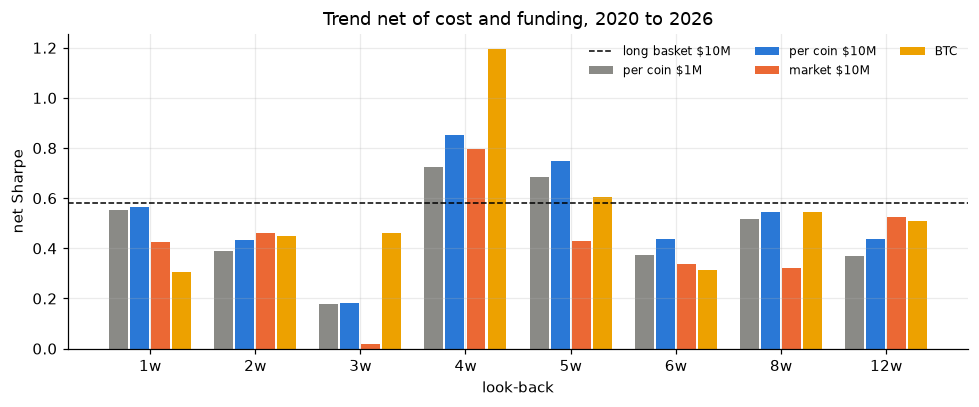

In [3]:
rows = []
for (b, L), r in results.items():
    w = weights[(b, L)]
    rows.append({'book': b, 'L': L, 'net': sharpe(r.net), 'gross': sharpe(r.gross),
                 'net_0x': sharpe(run(w, 0.0).net), 'net_2x': sharpe(run(w, 2.0).net),
                 'return_%': r.net.mean() * 5200, 'cost_%': r.cost.mean() * 5200,
                 'funding_%': r.funding.mean() * 5200, 'turnover': r.turnover.mean()})
grid = pd.DataFrame(rows)
print(grid.pivot(index='L', columns='book', values='net')[list(BOOKS)].round(2))
print()
print(grid.set_index(['book', 'L']).round(2))
print()
for k, r in references.items():
    print(f'{k:18} net Sharpe {sharpe(r.net):+.2f}   return {r.net.mean() * 5200:+.1f}% a year')

fig, ax = plt.subplots(figsize=(9, 3.8))
x = np.arange(len(LOOKBACKS)); wd = 0.2
piv = grid.pivot(index='L', columns='book', values='net')
for i, (b, colour) in enumerate(zip(BOOKS, [GREY, BLUE, ORANGE, YELLOW])):
    ax.bar(x + (i - 1.5) * wd, piv[b], width=wd - 0.02, color=colour, label=b)
ax.axhline(sharpe(references['long basket $10M'].net), color='k', ls='--', lw=1, label='long basket $10M')
ax.axhline(0, color='k', lw=0.6)
ax.set_xticks(x); ax.set_xticklabels([f'{L}w' for L in LOOKBACKS]); ax.set_xlabel('look-back')
ax.set_ylabel('net Sharpe'); ax.set_title('Trend net of cost and funding, 2020 to 2026')
ax.legend(frameon=False, ncol=3, fontsize=8)
plt.tight_layout(); plt.show()

Every book earns at every lookback, though the market book barely clears zero at 3 weeks. Four weeks is the best lookback in every book, 0.85 per coin on \$10M coins, 0.80 for the market book and 1.19 for BTC, against 0.58 for holding the basket, $-0.60$ for shorting it and 0.71 for holding BTC. Persistence, the one-week lookback, makes 0.57 per coin.

The surface is ragged. Five weeks is close behind 4 for the per coin books, 0.75 on \$10M coins, but 3 weeks sits in a hole, 0.18 per coin and 0.02 for the market book, between 0.43 at 2 weeks and 0.85 at 4. BTC alone has no hole. A Sharpe that moves fourfold for one week of lookback is not a smooth rewarded horizon. The edge sits at 4 and 5 weeks, not across a band.

Cost is not the constraint at these turnovers. Doubling it moves the 4-week per coin \$10M book from 0.85 to 0.81. Funding is the bigger drag, 6.4% a year on the per coin book and 12% on the market book, which spends more time long in hot funding.

The \$1M book trails or ties the \$10M one at every lookback. It holds the same liquid coins plus the smaller ones, so the smaller ones pull it down.

## Year by year

The same books split by calendar year, at lookbacks 1, 4 and 12 weeks.

In [4]:
yearly = {}
for b in BOOKS:
    for L in [1, 4, 12]:
        r = results[(b, L)].net
        yearly[f'{b} L={L}'] = r.groupby(r.index.year).apply(sharpe)
for k, r in references.items():
    yearly[k] = r.net.groupby(r.net.index.year).apply(sharpe)
print(pd.DataFrame(yearly).T.round(2))

day                 2020  2021  2022  2023  2024  2025  2026
per coin $1M L=1    0.77  1.16  0.59  0.40  0.60  0.23 -1.52
per coin $1M L=4    1.05  1.65  0.71  0.18 -0.44  1.56 -0.74
per coin $1M L=12   0.32  1.21  0.55 -0.75 -0.31  0.67 -0.22
per coin $10M L=1   0.53  1.12  0.71  0.63  0.72  0.19 -0.93
per coin $10M L=4   1.07  1.70  0.80  0.83  0.25  1.16 -0.65
per coin $10M L=12  0.32  1.24  0.57 -0.31  0.52  0.01 -0.27
market $10M L=1    -0.16  1.01 -0.47  0.97  1.25  0.16 -0.82
market $10M L=4    -0.64  1.74  0.77  1.07  0.44  1.28 -0.54
market $10M L=12   -0.47  1.18  0.98 -0.03  0.91 -0.07  0.08
BTC L=1             0.69  0.84  0.13 -0.03 -0.00  0.25 -0.20
BTC L=4             2.31  1.78  1.07  1.77  0.43  0.55 -0.34
BTC L=12            2.62  0.66  0.63 -0.28  0.53  0.53 -1.06
long basket $10M    2.40  2.12 -1.65  1.39  0.75 -0.86 -0.11
short basket $10M  -2.43 -2.12  1.64 -1.41 -0.77  0.82  0.08
long BTC            2.17  0.86 -1.79  1.90  1.60 -0.12 -0.18


The 4-week per coin \$10M book is positive in every full year from 2020 to 2025, from 0.25 in 2024 to 1.70 in 2021, and positive in the 2022 bear at 0.80 while holding the basket lost $-1.65$.

2026 breaks it. Every trend book but the 12-week market book is negative in 2026 so far, the year coins stopped moving together. The market book also lost in 2020.

BTC alone looks best on the full sample but leans on 2020 and 2021, at 2.31 and 1.78, and is weak from 2024.

## Small coins against liquid coins

The \$1M book is the \$10M coins plus every coin trading \$1M to \$10M a day. To see what the smaller coins contribute on their own, run the per coin rule on three sets. Small coins only, liquid coins only, and both together. Report each set's share of the combined book's weight, its years at 4 weeks, and how closely the small and liquid books move together.

In [5]:
def band(L, lo, hi):
    sig = np.sign(W.rolling(L, min_periods=L).sum()).shift(1)
    elig = (LIQ >= lo) & (LIQ < hi) & VOL.notna() & (VOL > 0) & sig.notna()
    raw = (sig / VOL).where(elig)
    return raw.div(raw.abs().sum(axis=1), axis=0)

rows = []
for L in LOOKBACKS:
    small, liquid, both = run(band(L, 1e6, 1e7)), run(band(L, 1e7, np.inf)), run(band(L, 1e6, np.inf))
    wb = band(L, 1e6, np.inf).fillna(0.0)
    rows.append({'L': L, 'small only': sharpe(small.net), 'small gross': sharpe(small.gross),
                 'liquid only': sharpe(liquid.net), 'both': sharpe(both.net),
                 'small share of weight': wb.abs().where(LIQ < 1e7).sum(axis=1).mean()})
print('net Sharpe')
print(pd.DataFrame(rows).set_index('L').round(2))
print()
small4, liquid4 = run(band(4, 1e6, 1e7)).net, run(band(4, 1e7, np.inf)).net
print('L = 4, by year')
print(pd.DataFrame({'small only': small4.groupby(small4.index.year).apply(sharpe),
                    'liquid only': liquid4.groupby(liquid4.index.year).apply(sharpe)}).T.round(2))
print(f'correlation of small and liquid books at L = 4   {small4.corr(liquid4):.2f}')

net Sharpe
    small only  small gross  liquid only  both  small share of weight
L                                                                    
1         0.40         0.66         0.57  0.55                   0.38
2         0.51         0.70         0.43  0.39                   0.38
3         0.45         0.63         0.18  0.18                   0.38
4         0.45         0.63         0.85  0.72                   0.38
5         0.57         0.73         0.75  0.68                   0.38
6         0.33         0.49         0.44  0.37                   0.38
8         0.23         0.40         0.55  0.52                   0.38
12        0.26         0.42         0.44  0.37                   0.36

L = 4, by year
day          2020  2021  2022  2023  2024  2025  2026
small only   2.11  1.45 -0.23 -0.23 -1.90  1.27 -0.78
liquid only  1.07  1.70  0.80  0.83  0.25  1.16 -0.65
correlation of small and liquid books at L = 4   0.61


Small coins earn on their own, from 0.23 to 0.57 net. At 2 and 3 weeks they beat the liquid coins, 0.51 and 0.45 against 0.43 and 0.18. At every other lookback they trail, and at 4 weeks they make 0.45 against 0.85.

They are far less reliable. At 4 weeks the small book lost in 2022, 2023 and 2024, down to $-1.90$ in 2024, while the liquid book was positive every full year to 2025.

Most of what they earn is the same market bet. The two books correlate 0.61.

They take about 38% of the combined book's weight, which is why mixing them in lands between the two, at 0.72. Their cost of 15 bps each way is a guess, so their true number is likely lower.

## Walk-forward

Picking the best lookback after seeing the whole sample flatters it. Pick it inside each fold instead. Keep the first two years as history, split the rest into six test blocks, and trade each block on the lookback with the best net Sharpe over everything before it. The stitched test blocks are out of sample by construction. Set them against fixed 4 weeks and against all lookbacks averaged over the same weeks.

Then the probability of backtest overfitting. Split the weeks into 16 blocks. Over every way of using half the blocks to pick the best lookback, count how often that pick lands in the bottom half on the other blocks. Near zero means the choice carries information. At a half or above the winner is luck, and the average of the grid is the honest book to quote.

In [6]:
wf = {}
for bk in BOOKS:
    nets = pd.DataFrame({L: results[(bk, L)].net for L in LOOKBACKS}).dropna()
    oos, picked = gate.walk_forward(nets, folds=6, min_train=104)
    first = oos.index[0]
    wf[bk] = {'out of sample from': str(first.date()), 'lookbacks picked': ' '.join(str(p) for p in picked),
              'walk-forward Sharpe': round(sharpe(oos), 2), 'fixed L=4, same weeks': round(sharpe(nets[4].loc[first:]), 2),
              'grid averaged, same weeks': round(sharpe(nets.mean(axis=1).loc[first:]), 2),
              'probability of overfit': round(gate.pbo(nets), 2)}
print(pd.DataFrame(wf))

                          per coin $1M per coin $10M  market $10M          BTC
out of sample from          2022-05-01    2022-05-01   2022-05-01   2022-05-01
lookbacks picked           8 4 4 4 4 4   4 4 4 4 4 4  4 4 4 4 4 4  4 4 4 4 4 4
walk-forward Sharpe               0.31          0.72         0.72         0.82
fixed L=4, same weeks              0.5          0.72         0.72         0.82
grid averaged, same weeks         0.24          0.42         0.38         0.33
probability of overfit            0.46          0.29          0.4         0.13


From May 2022 the past picked 4 weeks at every fold in every book, except the first fold of the \$1M book, which picked 8. Chosen in fold, the per coin and market books on \$10M coins both make 0.72 and BTC 0.82, the same as fixing 4 weeks, since 4 is what every fold chose. The \$1M book makes 0.31 against 0.50 for fixed 4 weeks, the one fold that picked 8 cost it.

The probability that picking the best lookback is luck is 0.29 per coin, 0.40 for the market book, 0.13 for BTC and 0.46 for the \$1M book. All sit below a half. Four weeks is a consistent choice from the past alone, even with a hole at 3.

## How much of it is a market bet

When most coins rise together, the per coin book ends up long almost everything, which is just a bet on the market. Split its profit exactly into two parts. The market part is its net long or short exposure times the basket. The rest nets to zero, and earns only from picking which coins to be long and short.

Then test the rest twice. Remove its hidden exposure to how strongly coins follow the market, called beta. And cap every weekly move at 2 standard deviations, to see whether a few huge moves carry it.

In [7]:
b10 = basket(1e7).fillna(0.0)
mk = np.log1p((b10 * R).sum(axis=1))
beta = pd.DataFrame({c: W[c].rolling(26, min_periods=13).cov(mk) for c in W.columns}).div(mk.rolling(26, min_periods=13).var(), axis=0).shift(1)
z = W / VOL
R_capped = np.expm1((z.clip(-2, 2) * VOL).where(W.notna(), np.log1p(R)))

rows = []
for L in LOOKBACKS:
    w = weights[('per coin $10M', L)].fillna(0.0)
    mkt_part = b10.mul(w.sum(axis=1), axis=0)
    rest = w - mkt_part
    beta_neutral = rest - b10.mul((rest * beta).sum(axis=1), axis=0)
    full, m, r = run(w, 0.0).gross, run(mkt_part, 0.0).gross, run(rest, 0.0).gross
    capped = ((rest * R_capped).sum(axis=1)).loc[r.index]
    rows.append({'L': L, 'full': sharpe(full), 'market part': sharpe(m), 'rest': sharpe(r),
                 'rest share of profit': r.sum() / full.sum(), 'rest, beta removed': sharpe(run(beta_neutral, 0.0).gross),
                 'rest, moves capped': sharpe(capped),
                 'corr with market book': results[('per coin $10M', L)].net.corr(results[('market $10M', L)].net)})
print('gross Sharpe, per coin $10M book')
print(pd.DataFrame(rows).set_index('L').round(2))
print()
wt = W.where(LIQ >= 1e7); avg = wt.mean(axis=1); rel = wt.sub(avg, axis=0); rv = rel.rolling(12, min_periods=8).std().shift(1)
for L in [1, 2, 4]:
    past = rel.rolling(L, min_periods=L).sum() / (rv * np.sqrt(L)); nxt = (rel / rv).shift(-1)
    ic = past.corrwith(nxt, axis=1, method='spearman')[(past.notna() & nxt.notna()).sum(axis=1) >= 20].dropna()
    print(f'coin vs market rank correlation, $10M coins, L={L}   {ic.mean():+.3f}   t {ic.mean() / ic.std() * np.sqrt(len(ic)):+.1f}')

gross Sharpe, per coin $10M book
    full  market part  rest  rest share of profit  rest, beta removed  \
L                                                                       
1   0.72         0.56  0.88                  0.24                0.93   
2   0.58         0.35  1.09                  0.42                1.18   
3   0.32         0.15  0.81                  0.54                0.95   
4   1.00         0.82  0.93                  0.20                0.82   
5   0.88         0.78  0.70                  0.15                0.67   
6   0.58         0.55  0.25                  0.09                0.47   
8   0.68         0.63  0.40                  0.10                0.53   
12  0.58         0.53  0.37                  0.10                0.15   

    rest, moves capped  corr with market book  
L                                              
1                 0.55                   0.85  
2                 0.82                   0.87  
3                 0.54                   0.9

The per coin book is mostly a market bet. At 4 weeks the market part carries 80% of its profit, and its returns correlate 0.80 with the market book.

The rest still earns, 0.93 gross at 4 weeks. It survives removing beta, 0.82, and capping every move at 2 standard deviations, 0.75. It is strongest at 2 weeks, 1.09 gross, and fades from 6. Long the coins that rose and short the coins that fell earns something beyond the market among liquid coins.

That clashes with the rank view. Ranked week by week, liquid coins still snap back slightly against the market, $-0.021$ at 1 week and $-0.025$ at 2, about 2 standard errors from zero. Ranks and money disagree, and this notebook does not resolve why. The rest is an open lead, not a finding.

## Verdict

The lane does not close on the sweep. Trend on liquid crypto perps earns at every lookback and in every full year to 2025, 0.85 net per coin and 0.80 for the market book at 4 weeks, and 4 weeks is what a walk forward chooses from the past alone at every fold. It is mostly a bet on the market's own trend.

The lookback surface is ragged. Three weeks earns almost nothing between 2 and 4, so the edge sits at 4 and 5 weeks rather than across a smooth band of horizons. 2026 is negative for every book but one.